In [1]:
import matplotlib.pyplot as plt
import numpy as np

from dipy.core.gradients import gradient_table
from dipy.data import get_fnames, get_sphere
from dipy.direction import peak_directions, peaks_from_model
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti
from dipy.reconst.csdeconv import auto_response_ssst, recursive_response
from dipy.reconst.rumba import RumbaSDModel
from dipy.segment.mask import median_otsu
from dipy.sims.voxel import single_tensor_odf
from dipy.viz import actor, window

import numpy as np
from dipy.core.sphere import disperse_charges, Sphere, HemiSphere
from dipy.data import get_sphere
from dipy.reconst.shm import sf_to_sh, sh_to_sf
from dipy.sims.voxel import multi_tensor_odf
from dipy.viz import window, actor


sphere = get_sphere('repulsion724')

/tmp/ipykernel_3704294/219153024.py:23: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  sphere = get_sphere('repulsion724')


In [2]:


fod_rumba = np.load('../../outputs/fods_data2/fod_rumba.npy')

meta = np.load('../../outputs/fods_data2/fod_metadata.npz', allow_pickle=True)
fod_b3s = np.load('../../outputs/fods_data_slice5/fod_b3s.npy')
fod_b3t = np.load('../../outputs/fods_data_slice/fod_b3t.npy')
fod_all = np.load('../../outputs/fods_data_slice/fod_all.npy')

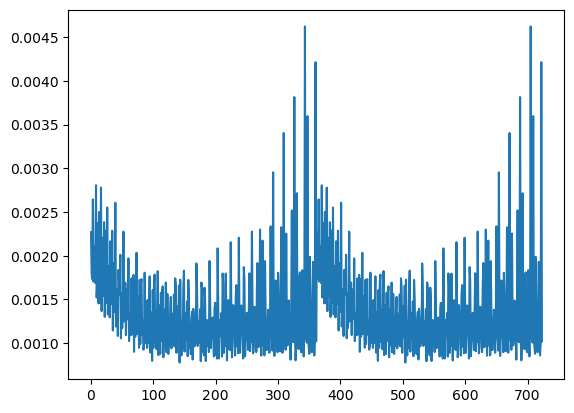

In [3]:
plt.plot(fod_b3s[fod_b3s.sum(-1)> 0][1])

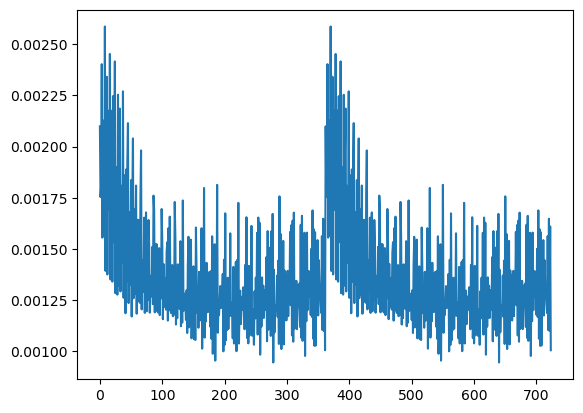

In [4]:
_ = plt.plot(fod_b3t[fod_b3t.sum(-1)> 0][1])

In [5]:
!export VTK_DEFAULT_RENDER_WINDOW_OFFSCREEN=1
!export PYOPENGL_PLATFORM=osmesa
!export MESA_GL_VERSION_OVERRIDE=3.3
!export MUJOCO_GL=osmesa
!export LIBGL_ALWAYS_SOFTWARE=1
!export MESA_GL_VERSION_OVERRIDE=3.3


In [6]:
def fa_from_fod(fod, eps=1e-12):
    # fod: (..., N_directions)
    mean = np.mean(fod, axis=-1, keepdims=True)
    num = np.sum((fod - mean)**2, axis=-1)
    den = np.sum(fod**2, axis=-1) + eps
    N = fod.shape[-1]
    return np.sqrt(N / (N - 1) * num / den)

In [7]:
fod_b3s.sum(-1).max()

np.float32(1.0000001)

In [8]:
fa_rumba = fa_from_fod(fod_rumba)
fa_b3s = fa_from_fod(fod_b3s)
fa_b3t = fa_from_fod(fod_b3t)
fa_all = fa_from_fod(fod_all)

In [9]:
fod_b3t[fa_b3t > 0.]

array([[0.00203066, 0.00201565, 0.0019787 , ..., 0.00108181, 0.00172611,
        0.00132948],
       [0.00209939, 0.00175396, 0.00180851, ..., 0.00110006, 0.0016108 ,
        0.001006  ],
       [0.00147472, 0.00150345, 0.00150672, ..., 0.00107475, 0.00080681,
        0.00105685],
       ...,
       [0.00096317, 0.0009774 , 0.0009596 , ..., 0.00177456, 0.00128479,
        0.00138325],
       [0.00105604, 0.00109856, 0.00112056, ..., 0.00154997, 0.00167786,
        0.00123261],
       [0.00153656, 0.00141081, 0.00148358, ..., 0.0012658 , 0.00122953,
        0.00113808]], shape=(5092, 724), dtype=float32)

In [10]:
fa_total = (fa_rumba + fa_b3s + fa_b3t + fa_all) / 4.0
# White background
fa_total[fa_total == 0] = 1.0

In [11]:
x_start, x_end = 10, -10
y_start, y_end = 3, -5
z_start, z_end = 34, 35

In [13]:
scene = window.Scene()
fodf_spheres = actor.odf_slicer(
    fod_rumba[x_start:x_end,y_start:y_end,z_start:z_end], sphere=sphere, norm=True, scale=0.7, colormap=None
)

bg = actor.slicer(fa_total[x_start:x_end,y_start:y_end,z_start:z_end], affine=np.eye(4), opacity=1., interpolation='nearest')  # tweak opacity
scene.add(bg)
scene.add(fodf_spheres)
window.record(scene=scene, out_path="full_brain_fod_rumba.png", size=(4000,4000))
#if interactive:
#    window.show(scene)

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen


In [15]:
scene = window.Scene()
fodf_spheres = actor.odf_slicer(
    fod_b3s[x_start:x_end,y_start:y_end,z_start:z_end], sphere=sphere, norm=True, scale=0.7, colormap=None
)
bg = actor.slicer(fa_total[x_start:x_end,y_start:y_end,z_start:z_end], affine=np.eye(4), opacity=1., interpolation='nearest')  # tweak opacity
#bg.display(z=fa_total.shape[2] // 2)   # pick a visible slice
scene.add(bg)
scene.add(fodf_spheres)
window.record(scene=scene, out_path="full_brain_fod_b3s_2.png", size=(4000,4000))
#if interactive:
#    window.show(scene)

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen


In [45]:
scene = window.Scene()
fodf_spheres = actor.odf_slicer(
    fod_all[x_start:x_end,y_start:y_end,z_start:z_end], sphere=sphere, norm=True, scale=0.7, colormap=None
)
#bg = actor.slicer(f_iso, affine=np.eye(4), opacity=1., interpolation='nearest')  # tweak opacity
#scene.add(bg)
scene.add(fodf_spheres)
window.record(scene=scene, out_path="full_brain_fod_all.png", size=(4000,4000))
#if interactive:
#    window.show(scene)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/no

In [21]:
x_start, x_end = 30, 40
y_start, y_end = 30, 40
z_start, z_end = 34, 35

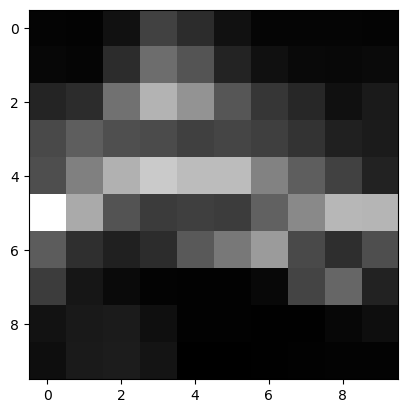

In [22]:
plt.imshow(fod_rumba.max(-1)[x_start:x_end,y_start:y_end,34], cmap='gray')

In [ ]:
scene = window.Scene()
fodf_spheres = actor.odf_slicer(
    fod_rumba[x_start:x_end,y_start:y_end,z_start:z_end], sphere=sphere, norm=True, scale=0.7, colormap=None
)
scene.background((1, 1, 1))
#bg = actor.slicer(f_iso, affine=np.eye(4), opacity=1., interpolation='nearest')  # tweak opacity
#scene.add(bg)
scene.add(fodf_spheres)
window.record(scene=scene, out_path="full_brain_fod_small.png", size=(400,400))
#if interactive:
#    window.show(scene)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/no

In [23]:
scene = window.Scene()
fodf_spheres = actor.odf_slicer(
    fod_b3s[x_start:x_end,y_start:y_end,z_start:z_end], sphere=sphere, norm=True, scale=0.7, colormap=None
)
scene.background((1, 1, 1))
#bg = actor.slicer(f_iso, affine=np.eye(4), opacity=1., interpolation='nearest')  # tweak opacity
#scene.add(bg)
scene.add(fodf_spheres)
window.record(scene=scene, out_path="full_brain_fod_b3s_small.png", size=(400,400))
#if interactive:
#    window.show(scene)

: 

In [ ]:
scene = window.Scene()
fodf_spheres = actor.odf_slicer(
    fod_b3s[x_start:x_end,y_start:y_end,z_start:z_end], sphere=sphere, norm=True, scale=0.7, colormap=None
)
scene.background((1, 1, 1))
#bg = actor.slicer(f_iso, affine=np.eye(4), opacity=1., interpolation='nearest')  # tweak opacity
#scene.add(bg)
scene.add(fodf_spheres)
window.record(scene=scene, out_path="full_brain_fod_b3s_small.png", size=(400,400))
#if interactive:
#    window.show(scene)

In [60]:
scene = window.Scene()
fodf_spheres = actor.odf_slicer(
    fod_b3t[x_start:x_end,y_start:y_end,z_start:z_end], sphere=sphere, norm=True, scale=0.7, colormap=None
)
scene.background((1, 1, 1))
#bg = actor.slicer(f_iso, affine=np.eye(4), opacity=1., interpolation='nearest')  # tweak opacity
#scene.add(bg)
scene.add(fodf_spheres)
window.record(scene=scene, out_path="full_brain_fod_b3t_small.png", size=(400,400))
#if interactive:
#    window.show(scene)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/no

In [61]:
scene = window.Scene()
fodf_spheres = actor.odf_slicer(
    fod_all[x_start:x_end,y_start:y_end,z_start:z_end], sphere=sphere, norm=True, scale=0.7, colormap=None
)
scene.background((1, 1, 1))
#bg = actor.slicer(f_iso, affine=np.eye(4), opacity=1., interpolation='nearest')  # tweak opacity
#scene.add(bg)
scene.add(fodf_spheres)
window.record(scene=scene, out_path="full_brain_fod_all_small.png", size=(400,400))
#if interactive:
#    window.show(scene)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/nouveau_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib64/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open nouveau: /usr/lib64/dri/no